# 01 - Exploratory Data Analysis (EDA)
## Online vs In-Store Shopping Behaviour Dataset

### Project
Shopping ML Project

### Objective
The goal of this notebook is to perform **Exploratory Data Analysis (EDA)** on the shopping behavior dataset to understand:

- Data structure
- Feature distributions
- Relationships between variables
- Target variable distribution
- Potential preprocessing steps

EDA helps us identify **patterns, anomalies, and feature relationships** before building machine learning models.

---

## Dataset Overview

This dataset simulates real-world consumer behavior including:

- Demographic information
- Digital habits
- Shopping patterns
- Logistics preferences
- Psychological factors

The **target variable** is:

**`shopping_preference`**

Possible values:

- Online
- Store
- Hybrid

This is a **multiclass classification problem**.

In [75]:
# Setup
import sys
sys.path.append("..")

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Load Dataset
We load the dataset using the project's `data_loader` utility to ensure paths remain consistent across the project.

In [76]:
from src.data_loader import load_raw_data

df = load_raw_data("online vs store shopping dataset.csv")

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Basic Dataset Information

In [77]:
df.shape

(11789, 25)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_days          

In [79]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


### Observations

- The dataset contains **11,789 rows**
- There are **25 columns**
- Most variables are **numerical**
- A few are **categorical**

Categorical columns include:

- `gender`
- `city_tier`
- `shopping_preference`

### Key Insights
1. Balanced Distribution: Most features have a roughly symmetric distribution, but some have high variance (monthly_income, monthly_online_orders).
2. Outliers Exist: Income, online spend, and online orders have extreme values that may need capping or log-transforming.
3. Online vs Store Habits: Median online orders are higher than store visits, hinting at a shift toward online shopping.
4. Trust and Tech-Savviness: Median scores around 5–6 show moderate trust and technology adoption among users.
5. Behavioral Scores: Impulse buying, free return importance, and brand loyalty show a range from 1–10, indicating diverse consumer psychology.

## Check Missing Values

In [80]:
df.isnull().sum()

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

### Observation

There are **no missing values** in the dataset.

## Target Variable Distribution

In [81]:
df["shopping_preference"].value_counts()

shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64

/var/folders/4c/8m_hgryj1t1fgvsq3j6bl9dr0000gn/T/ipykernel_58462/3026323281.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


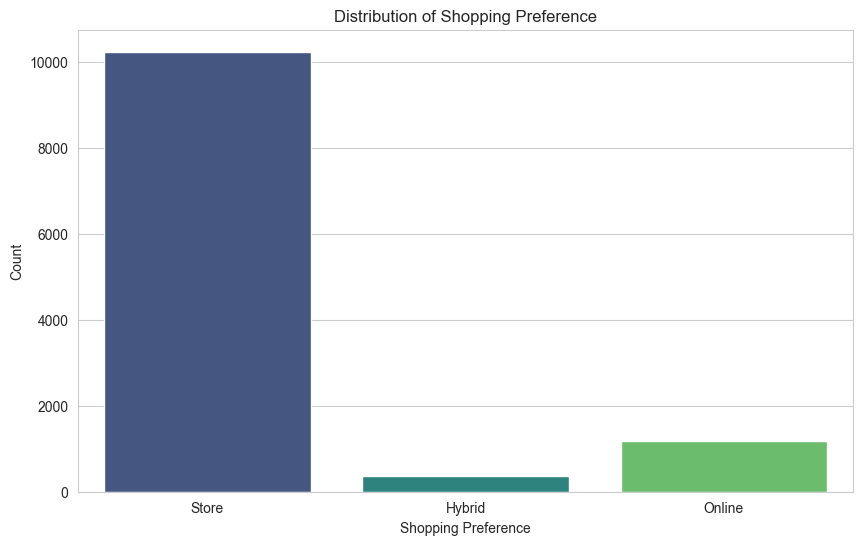

In [82]:
sns.countplot(
    data=df,
    x="shopping_preference",
    palette="viridis"
)

plt.title("Distribution of Shopping Preference")
plt.xlabel("Shopping Preference")
plt.ylabel("Count")

plt.show()

### Observations
1. Highly Imbalanced Classes:
	- The majority of users prefer Store shopping (≈87%).
	- Online shoppers are around 10%, and Hybrid shoppers are very few (≈3%).
2. Implications for Modeling:
	- Class imbalance may bias models toward predicting the Store class.
	- Consider resampling techniques (oversampling minority classes, undersampling majority) or class-weight adjustments when training classifiers.
3. Business Insights:
	- Despite the rise of online shopping, traditional store visits still dominate.
	- Hybrid shoppers are rare, highlighting an opportunity to target users who mix channels.

## Feature Type Separation

In [83]:
numerical_features = df.select_dtypes(include=["int64","float64"]).columns
categorical_features = df.select_dtypes(include=["object","string"]).columns

print("Numerical Features:", list(numerical_features))
print()
print("Categorical Features:", list(categorical_features))

Numerical Features: ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years', 'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance', 'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level']

Categorical Features: ['gender', 'city_tier', 'shopping_preference']


### Observations
1.	Numerical Features:
	- Many features are continuous or ordinal (e.g., monthly_income, daily_internet_hours, tech_savvy_score).
	- Some features represent counts (monthly_online_orders, monthly_store_visits) or scores (1–10 scales).
	- Distribution plots (histograms) help identify skewed features, potential outliers, and candidates for scaling/normalization.
2. Categorical Features:
	- gender and city_tier are demographic variables, likely requiring encoding (e.g., one-hot encoding).
	- shopping_preference is the target variable for our classification problem.
3. Next Steps for Preprocessing:
	- Handle skewed numerical distributions (log-transform, scaling).
	- Encode categorical variables.
	- Check for missing values (though dataset seems clean from earlier df.describe() output).
	- Consider feature engineering for behavioral features like monthly_online_orders or impulse_buying_score.

## Numerical Feature Distributions

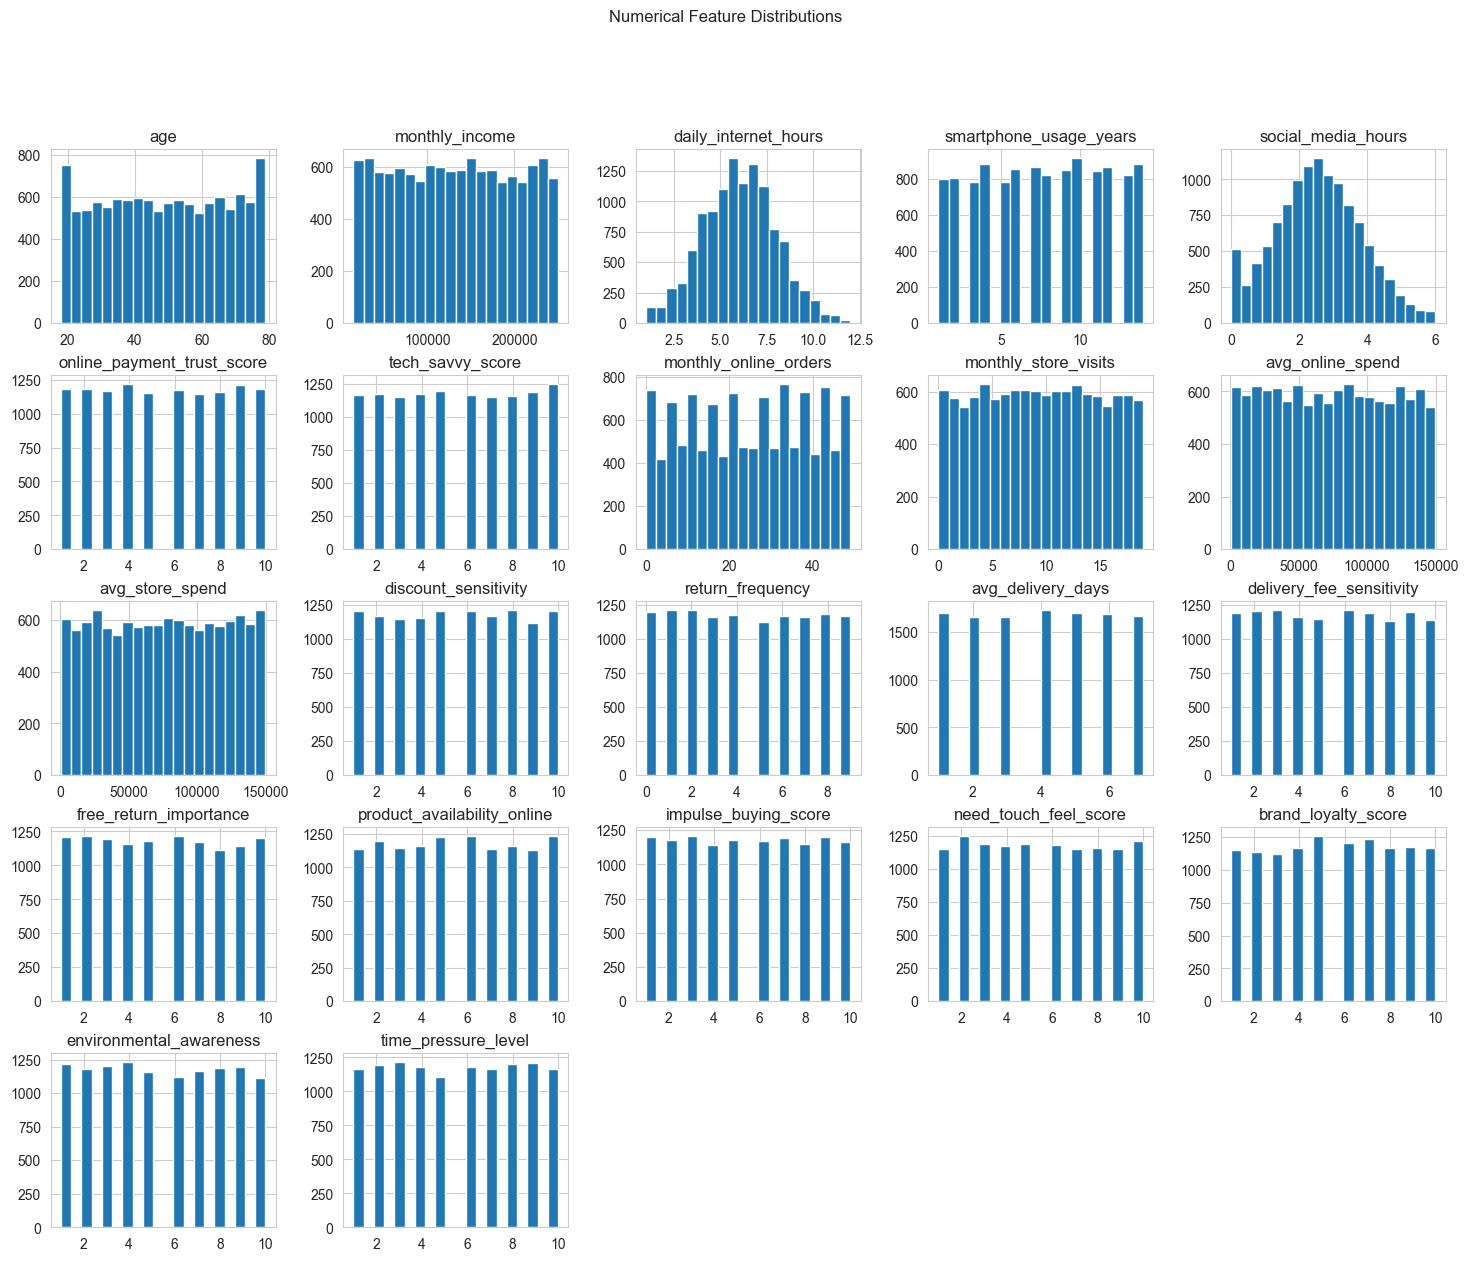

In [84]:
df[numerical_features].hist(
    bins=20,
    figsize=(18,14)
)

plt.suptitle("Numerical Feature Distributions")

plt.show()

### Observations

We examine distributions to detect:

- skewness
- abnormal values
- possible outliers

## Correlation Matrix

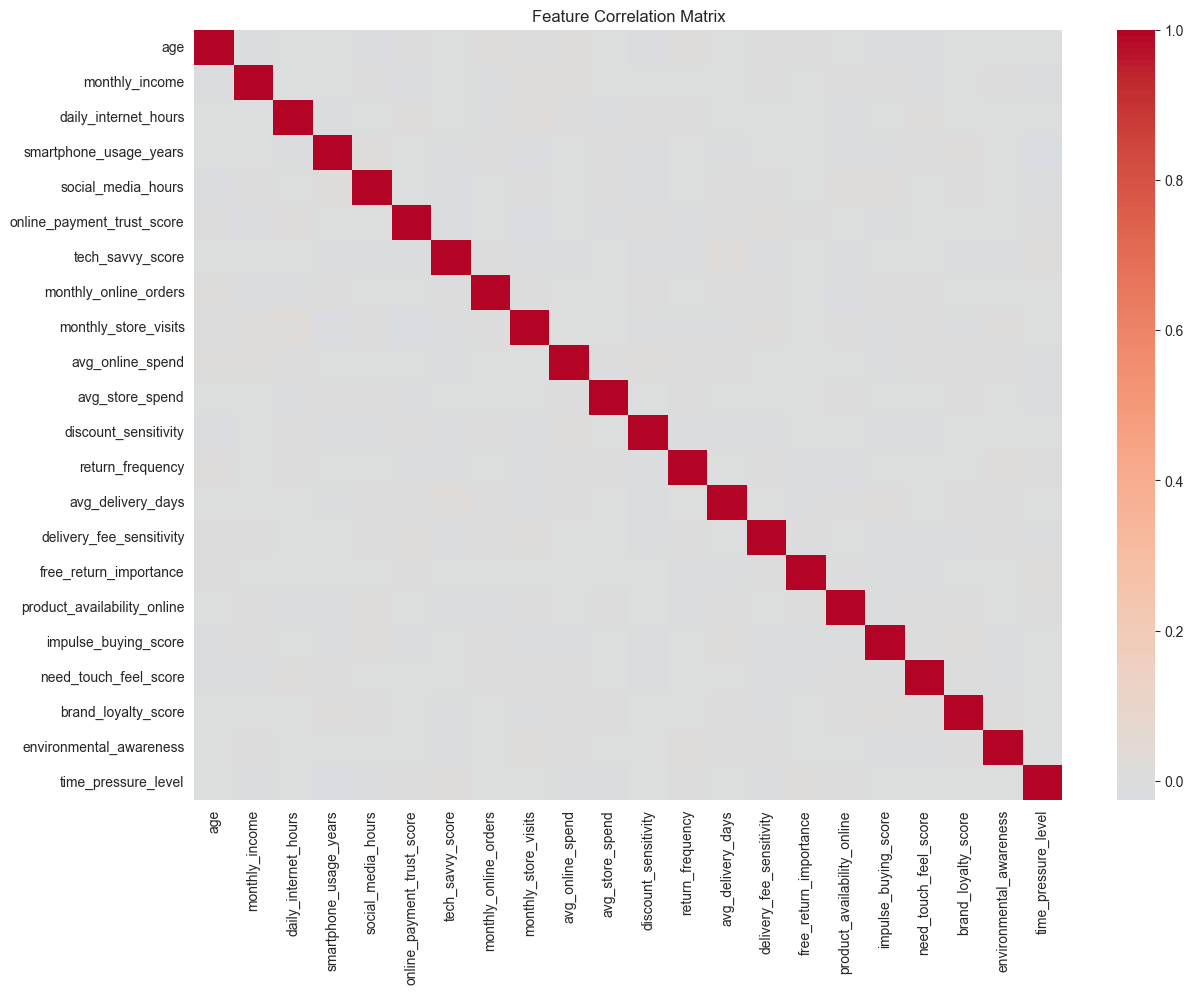

In [85]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

### Observations

Correlation helps identify:

- redundant features
- strong feature relationships
- possible multicollinearity

## Boxplots for Outlier Detection

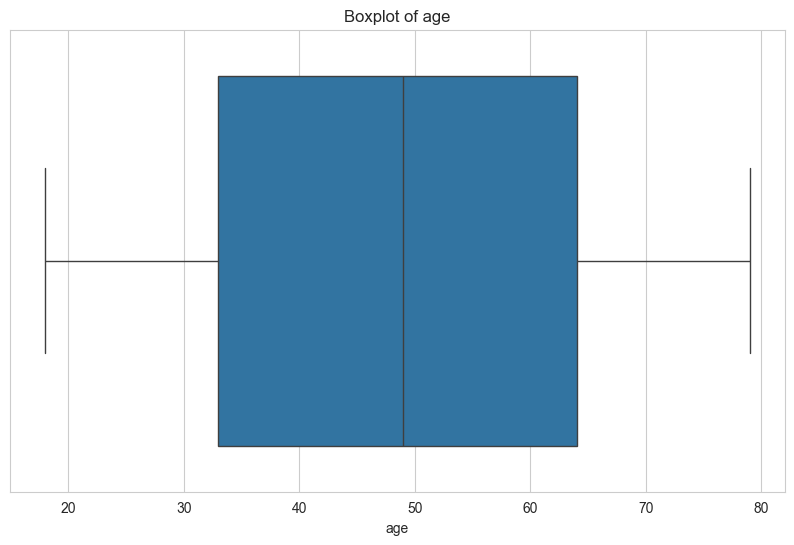

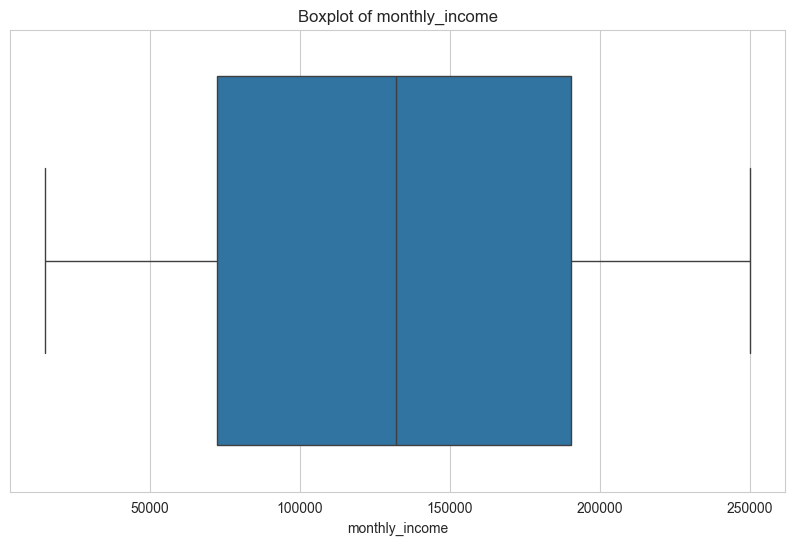

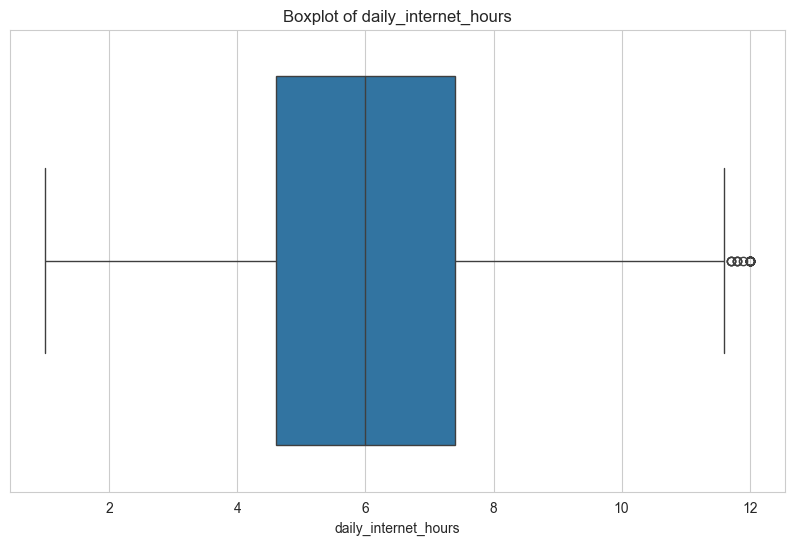

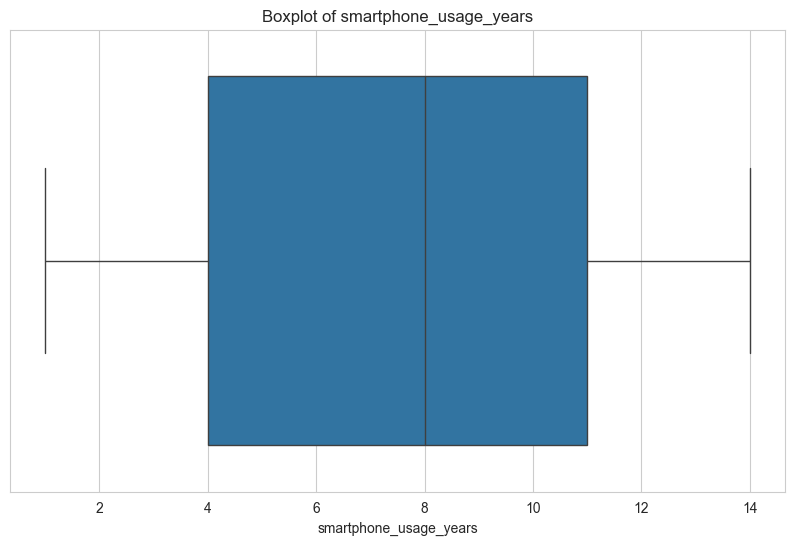

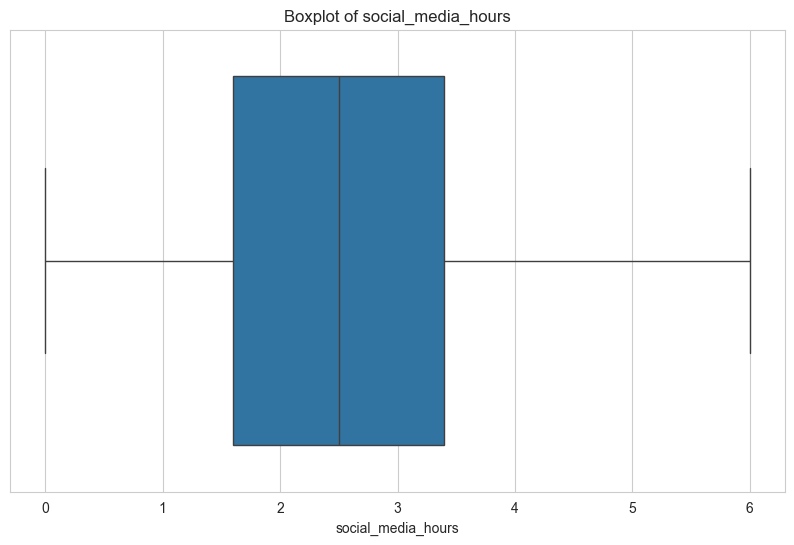

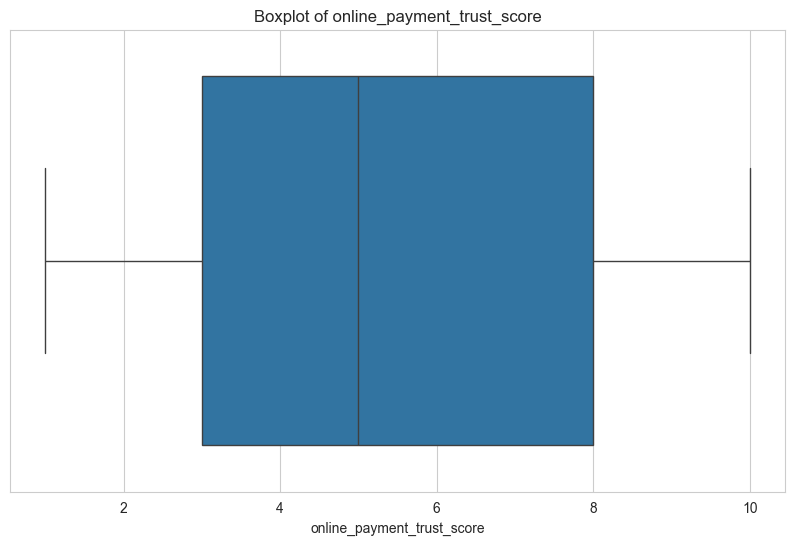

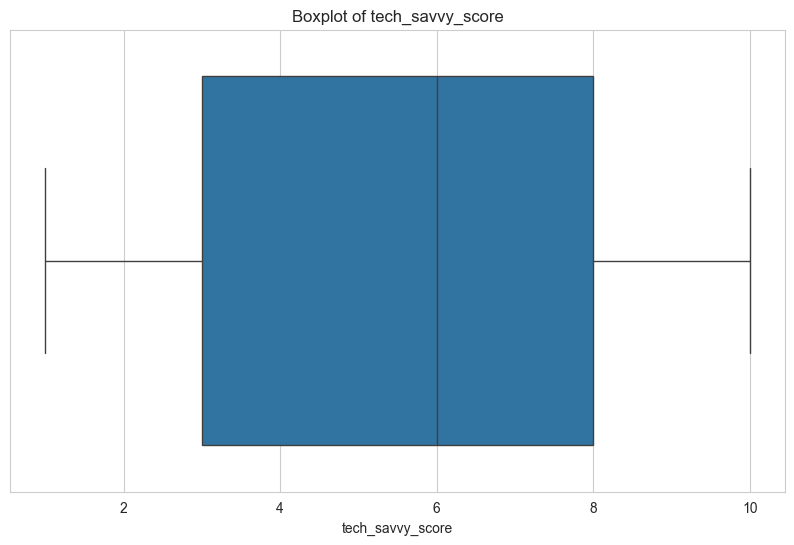

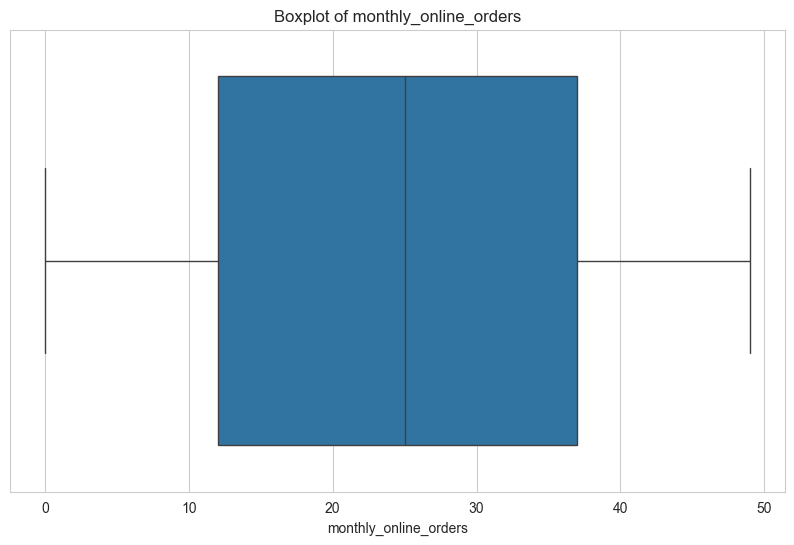

In [86]:
for col in numerical_features[:8]:
    
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Observation

Boxplots help detect:

- extreme values
- long-tailed distributions

## Categorical Feature Analysis

/var/folders/4c/8m_hgryj1t1fgvsq3j6bl9dr0000gn/T/ipykernel_58462/1002839857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


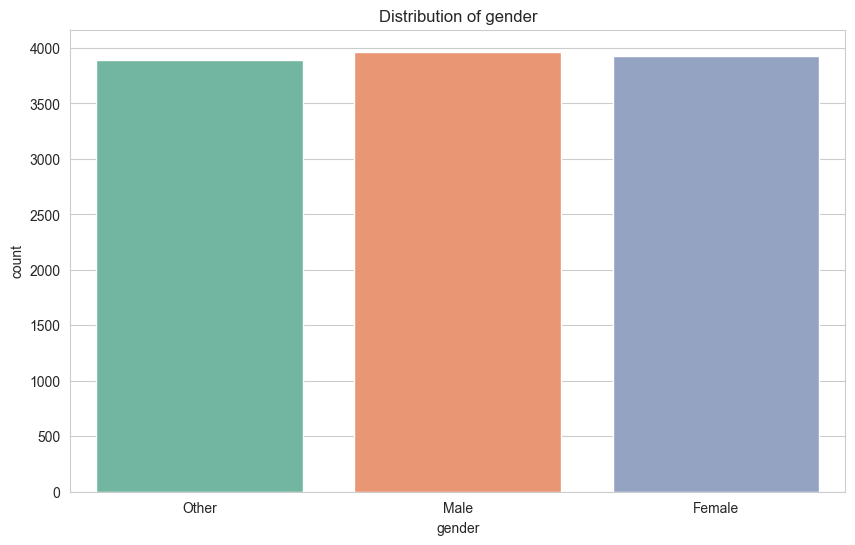

/var/folders/4c/8m_hgryj1t1fgvsq3j6bl9dr0000gn/T/ipykernel_58462/1002839857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


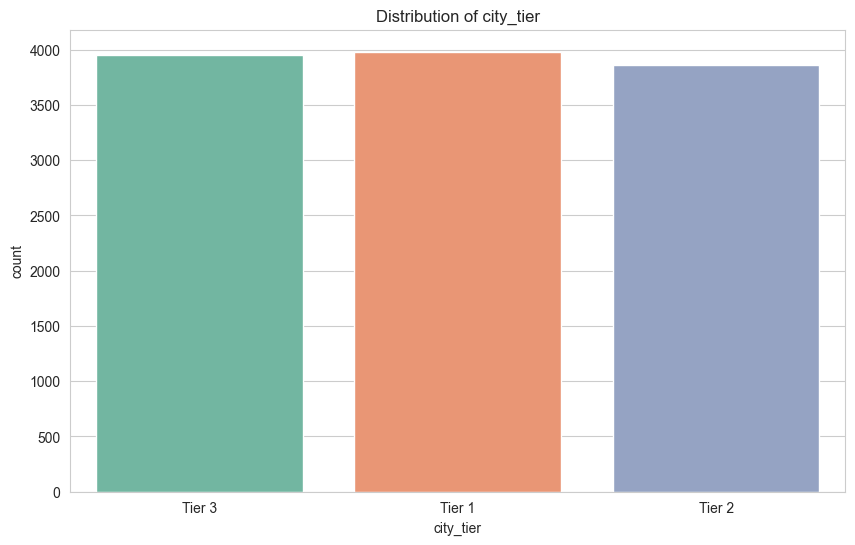

/var/folders/4c/8m_hgryj1t1fgvsq3j6bl9dr0000gn/T/ipykernel_58462/1002839857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


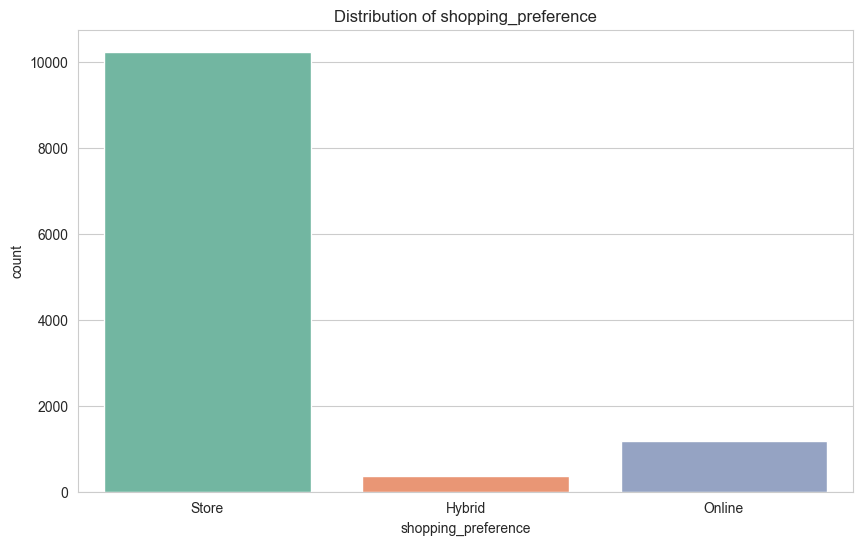

In [87]:
for col in categorical_features:
    
    sns.countplot(
        data=df,
        x=col,
        palette="Set2"
    )
    
    plt.title(f"Distribution of {col}")
    plt.show()

## Relationship Between Features and Target

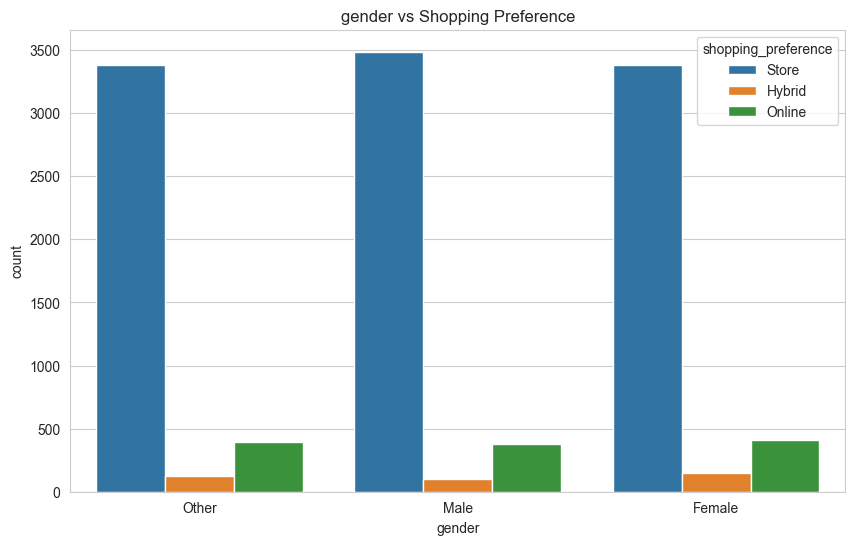

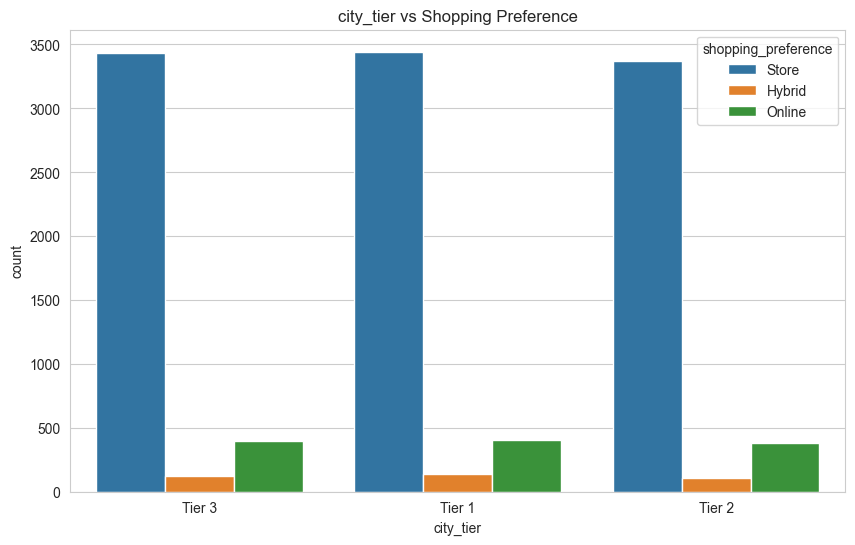

In [88]:
for col in categorical_features:
    
    if col != "shopping_preference":
        
        sns.countplot(
            data=df,
            x=col,
            hue="shopping_preference"
        )
        
        plt.title(f"{col} vs Shopping Preference")
        plt.show()

## Numerical Features vs Target

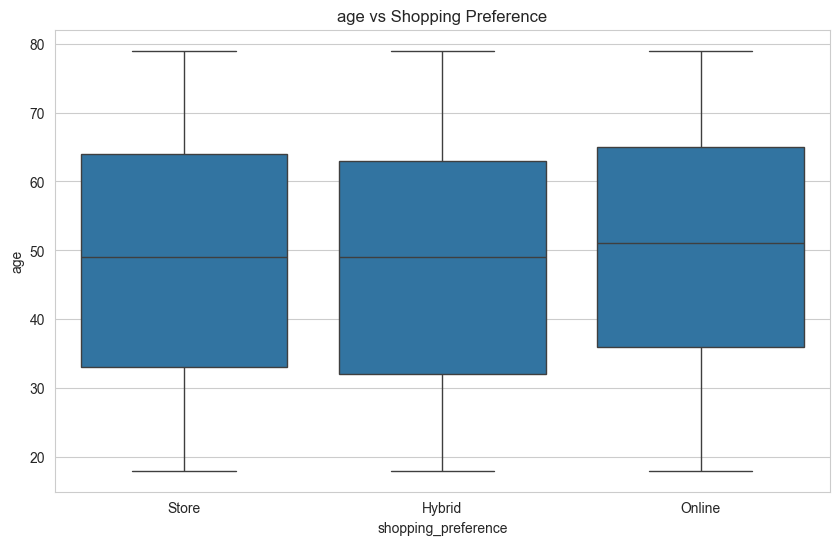

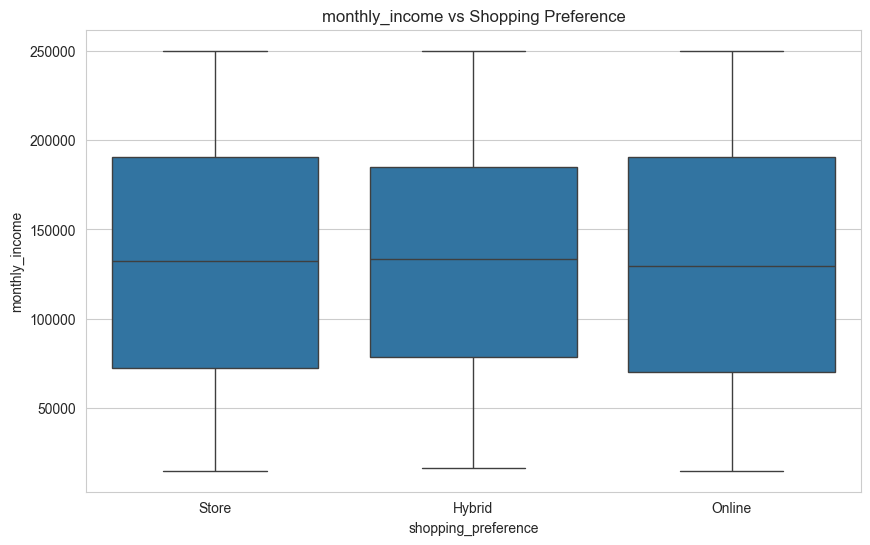

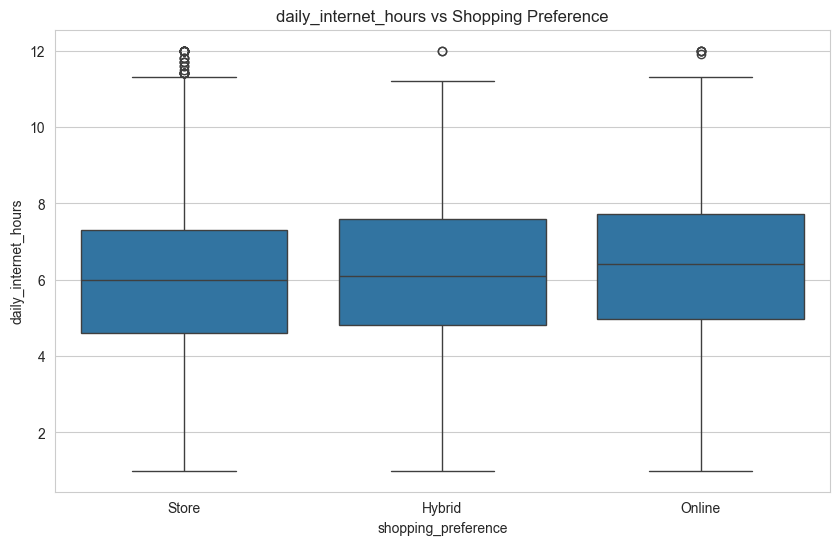

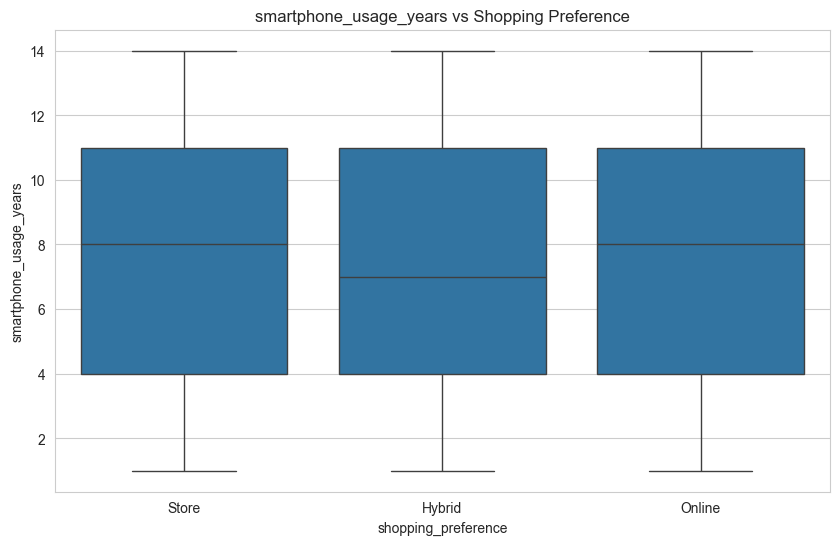

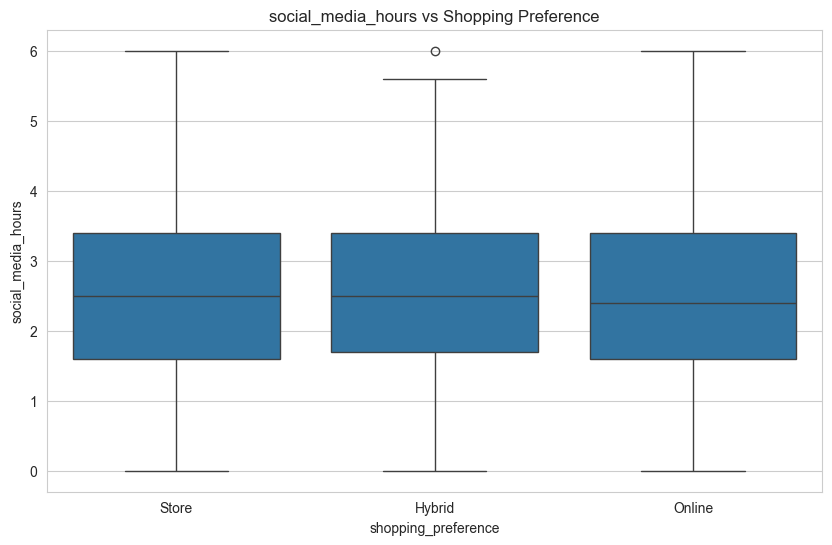

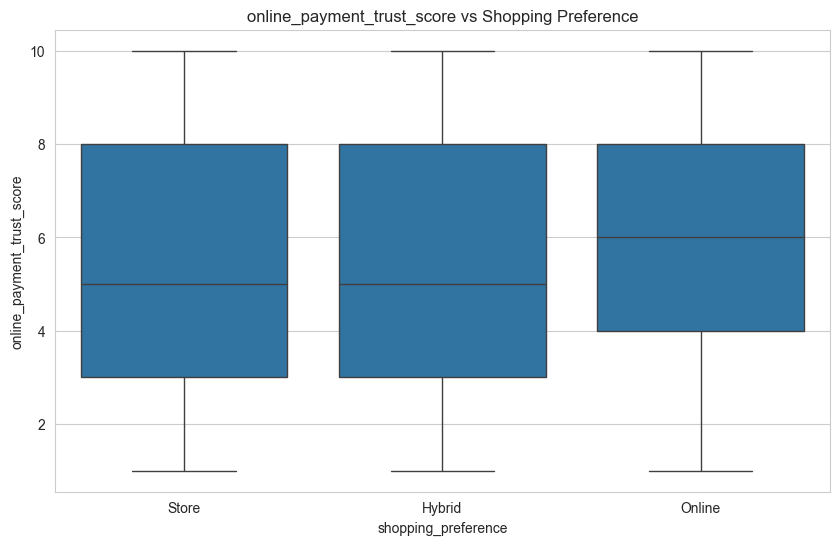

In [89]:
for col in numerical_features[:6]:
    
    sns.boxplot(
        data=df,
        x="shopping_preference",
        y=col
    )
    
    plt.title(f"{col} vs Shopping Preference")
    plt.show()

## Key Insights from EDA

### Dataset Characteristics

- ~11,800 observations
- 25 features
- Mostly numerical variables

### Target Variable

`shopping_preference` has three classes:

- Online
- Store
- Hybrid

### Data Quality

- No missing values
- No obvious data corruption

### Feature Groups

Numerical Features:
- age
- income
- digital behavior metrics
- purchasing behavior

Categorical Features:
- gender
- city_tier

### Next Steps

1. Encode categorical variables
2. Scale numerical features where necessary
3. Build preprocessing pipeline
4. Train baseline models

The next notebook will focus on:

**Logistic Regression Model**